# 03 — Feature Engineering
**Proyecto:** PredictRent — Predicción de precios de alquiler en Lima Metropolitana  
**Dataset:** `inmuebles_clean_v1.csv`  
**Objetivo:** Transformar y construir las variables que alimentarán los modelos.

---
## Índice
1. Carga y configuración
2. Transformación del target → `log1p(precio_usd)`
3. Eliminación de columnas no útiles
4. Encoding de variables categóricas
   - 4a. Target Encoding para `distrito_oficial`
   - 4b. One-Hot Encoding para `fuente`, `tipo_propiedad`, `mismatch_type`
5. Creación de features derivadas
6. Escalado de variables numéricas
7. División train / validation / test
8. Guardado de artefactos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

PROCESSED  = '../data/processed/'
MODELS     = '../models/'
FIGURES    = '../reports/figures/'

df = pd.read_csv(f'{PROCESSED}inmuebles_clean_v1.csv')
print(f'Shape inicial: {df.shape}')

Shape inicial: (3348, 75)


---
## 2. Transformación del target

**Justificación:** El EDA mostró que `precio_usd` tiene sesgo positivo alto (skewness > 2). Aplicar `log1p` produce una distribución más simétrica, lo que:
- Mejora la performance de modelos lineales (asumen normalidad en los residuos).
- Reduce el peso desproporcionado de outliers en la función de pérdida.
- Hace que el RMSE en escala log sea equivalente al MAPE en escala original.

`log1p(x) = log(1 + x)` evita problemas con valores en cero.

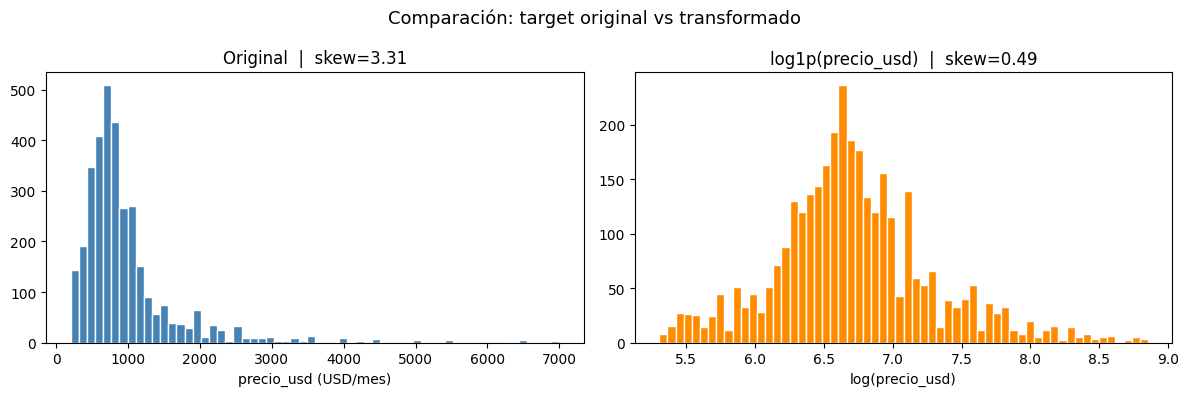

Skewness original:     3.307
Skewness log1p:        0.488


In [2]:
df['log_precio'] = np.log1p(df['precio_usd'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['precio_usd'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title(f'Original  |  skew={df["precio_usd"].skew():.2f}')
axes[0].set_xlabel('precio_usd (USD/mes)')

axes[1].hist(df['log_precio'], bins=60, color='darkorange', edgecolor='white')
axes[1].set_title(f'log1p(precio_usd)  |  skew={df["log_precio"].skew():.2f}')
axes[1].set_xlabel('log(precio_usd)')

plt.suptitle('Comparación: target original vs transformado', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES}03_target_log.png', dpi=150)
plt.show()

print(f'Skewness original:     {df["precio_usd"].skew():.3f}')
print(f'Skewness log1p:        {df["log_precio"].skew():.3f}')

---
## 3. Eliminación de columnas no útiles

Se eliminan columnas que:
- Son identificadores únicos (no aportan generalización).
- Son leaky (contienen información derivada del target o del proceso post-predicción).
- Son redundantes con otras features más confiables.

In [3]:
cols_eliminar = [
    'id_portal',          # Identificador único sin valor predictivo
    'url',                # URL del anuncio, identificador textual
    'titulo',             # Texto libre, requeriría NLP
    'distrito_portal',    # Distrito declarado por el portal (puede ser fraudulento)
                          #    ya tenemos distrito_oficial (geocodificado)
    'precio_usd',         # Target original; usaremos log_precio
    'h3_index_8',         # Índice H3 geoespacial de alta cardinalidad
                          #    ya tenemos lat/lon y dist_* que capturan la geografía
    'precision_geocoding',# Calidad interna del geocodificado, no disponible en producción
]

# Verificar que todas existen
existentes = [c for c in cols_eliminar if c in df.columns]
no_existen = [c for c in cols_eliminar if c not in df.columns]
if no_existen:
    print(f'  No encontradas (se omiten): {no_existen}')

df = df.drop(columns=existentes)
print(f'Shape después de eliminar columnas: {df.shape}')
print(f'Columnas eliminadas: {existentes}')

  No encontradas (se omiten): ['titulo', 'distrito_portal']
Shape después de eliminar columnas: (3348, 71)
Columnas eliminadas: ['id_portal', 'url', 'precio_usd', 'h3_index_8', 'precision_geocoding']


---
## 4. Encoding de variables categóricas

### 4a. Target Encoding para `distrito_oficial`

**¿Por qué Target Encoding y no One-Hot?**

- `distrito_oficial` tiene ~49 valores únicos. One-Hot Encoding generaría 49 columnas nuevas, lo que aumenta la dimensionalidad y puede causar problemas de multicolinealidad en modelos lineales.
- Target Encoding reemplaza cada distrito por la **media del target (log_precio)** en ese distrito, capturando la información de precio geográfico en una sola columna numérica.
- **Riesgo de data leakage:** Si calculamos la media con todas las filas incluyendo la que estamos codificando, el modelo puede memorizar el target. Solución: calcular la media **solo en el conjunto de entrenamiento** y aplicar el mismo mapeo al resto.

In [4]:
# Split antes del encoding para evitar data leakage
# Separamos primero train + val del test final
df_trainval, df_test = train_test_split(df, test_size=0.15, random_state=42)
df_train, df_val    = train_test_split(df_trainval, test_size=0.176, random_state=42)
# splits aproximados: 70% train / 15% val / 15% test

print(f'Train:      {len(df_train):>5} filas  ({len(df_train)/len(df)*100:.1f}%)')
print(f'Validation: {len(df_val):>5} filas  ({len(df_val)/len(df)*100:.1f}%)')
print(f'Test:       {len(df_test):>5} filas  ({len(df_test)/len(df)*100:.1f}%)')

Train:       2344 filas  (70.0%)
Validation:   501 filas  (15.0%)
Test:         503 filas  (15.0%)


In [5]:
# Target Encoding: calcular media de log_precio por distrito solo en train
target_enc_map = df_train.groupby('distrito_oficial')['log_precio'].mean()
global_mean    = df_train['log_precio'].mean()  # Fallback para distritos no vistos

for split in [df_train, df_val, df_test]:
    split['distrito_enc'] = split['distrito_oficial'].map(target_enc_map).fillna(global_mean)

# Guardar el mapa de encoding para usarlo en producción
joblib.dump({'map': target_enc_map, 'global_mean': global_mean},
            f'{MODELS}target_enc_distrito.joblib')

print('Target encoding aplicado. Muestra:')
print(target_enc_map.sort_values(ascending=False).head(10))

Target encoding aplicado. Muestra:
distrito_oficial
Miraflores           7.066188
San Isidro           6.981762
Punta Hermosa        6.907340
San Borja            6.875673
San Bartolo          6.838784
Santiago de Surco    6.823436
La Molina            6.770665
Barranco             6.708955
Magdalena del Mar    6.646928
Punta Negra          6.599969
Name: log_precio, dtype: float64


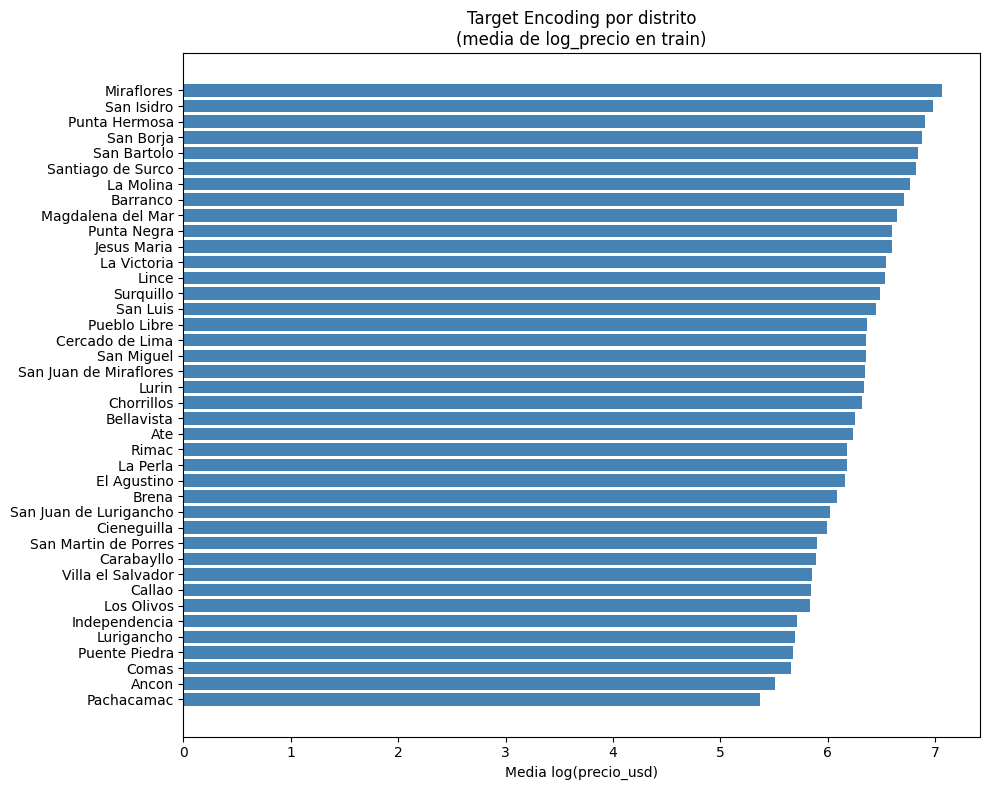

In [6]:
# Visualizar el ranking de distritos por encoding
fig, ax = plt.subplots(figsize=(10, 8))
enc_sorted = target_enc_map.sort_values(ascending=True)
ax.barh(enc_sorted.index, enc_sorted.values, color='steelblue')
ax.set_title('Target Encoding por distrito\n(media de log_precio en train)', fontsize=12)
ax.set_xlabel('Media log(precio_usd)')
plt.tight_layout()
plt.savefig(f'{FIGURES}03_target_encoding_distritos.png', dpi=150)
plt.show()

### 4b. One-Hot Encoding para variables de baja cardinalidad

Para variables con pocos valores únicos (`fuente`, `tipo_propiedad`, `mismatch_type`) usamos One-Hot Encoding — es seguro porque no genera demasiadas columnas.

In [7]:
ohe_cols = ['fuente', 'tipo_propiedad', 'mismatch_type']

for split in [df_train, df_val, df_test]:
    for col in ohe_cols:
        dummies = pd.get_dummies(split[col], prefix=col, drop_first=True, dtype=int)
        split[dummies.columns] = dummies

# Verificar que los tres splits tienen las mismas columnas generadas
# (puede haber diferencias si una categoría no aparece en algún split)
all_cols = set(df_train.columns) | set(df_val.columns) | set(df_test.columns)
for split in [df_train, df_val, df_test]:
    for col in all_cols:
        if col not in split.columns:
            split[col] = 0

print(f'Nuevas columnas OHE creadas: {[c for c in df_train.columns if any(c.startswith(p) for p in ohe_cols)]}')

Nuevas columnas OHE creadas: ['fuente', 'tipo_propiedad', 'mismatch_type', 'fuente_properati', 'fuente_urbania', 'tipo_propiedad_Departamento', 'mismatch_type_frontera', 'mismatch_type_ninguno']


---
## 5. Creación de features derivadas

Features construidas a partir de combinaciones de variables existentes que pueden capturar relaciones no lineales.

In [8]:
def crear_features_derivadas(df):
    df = df.copy()
    
    # Ratio área / baños: densidad de servicio sanitario
    df['ratio_area_banos'] = df['area_final_m2'] / (df['banos'] + 1)
    
    # Interacción área × amenities_count: propiedad grande + amenities = premium
    df['area_x_amenities'] = df['area_final_m2'] * df['amenities_count']
    
    # Feature de zona premium: cerca del mar y cerca del centro
    df['es_zona_premium'] = (
        (df['dist_mar_km'] < df['dist_mar_km'].quantile(0.25)) &
        (df['dist_centro_km'] < df['dist_centro_km'].quantile(0.25))
    ).astype(int)
    
    # Antigüedad al cuadrado: el efecto de la edad puede ser no lineal
    df['antiguedad_sq'] = df['antiguedad_anios'] ** 2
    
    # Densidad de POI cercanos: suma de supermercados + bancos + universidades en 1km
    poi_cols = [c for c in df.columns if 'count_1km' in c]
    if poi_cols:
        df['total_poi_1km'] = df[poi_cols].sum(axis=1)
    
    return df

df_train = crear_features_derivadas(df_train)
df_val   = crear_features_derivadas(df_val)
df_test  = crear_features_derivadas(df_test)

nuevas = ['ratio_area_banos', 'area_x_amenities', 'es_zona_premium', 'antiguedad_sq', 'total_poi_1km']
print('Features derivadas creadas:')
for f in nuevas:
    if f in df_train.columns:
        print(f'  - {f}')

Features derivadas creadas:
  - ratio_area_banos
  - area_x_amenities
  - es_zona_premium
  - antiguedad_sq
  - total_poi_1km


---
## 6. Selección de features finales y escalado

**¿Cuándo escalar?** Los modelos basados en árboles (Random Forest, XGBoost) son invariantes al escalado. Los modelos lineales (Ridge, Lasso) son muy sensibles a la escala — una feature en metros cuadrados (0–500) dominaría sobre una en kilómetros (0–30) sin escalado.

**Estrategia:** Guardamos dos versiones de los features:
- `X_train_scaled` → para modelos lineales.
- `X_train` (sin escalar) → para modelos de árbol.

In [9]:
# Definir features finales (excluir target, originales ya codificadas y texto)
COLS_EXCLUIR = [
    'log_precio',
    'distrito_oficial',
    'fuente',
    'tipo_propiedad',
    'mismatch_type',
]
object_cols = df_train.select_dtypes(include='object').columns.tolist()
COLS_EXCLUIR += object_cols
FEATURES = [c for c in df_train.columns if c not in COLS_EXCLUIR]

# --- Clasificar features por tipo para tratarlas correctamente ---
# BOOLEANAS: columnas tiene_*, flags creadas (es_estudio, es_zona_premium, cocheras_informadas) y OHE (fuente_*, tipo_propiedad_*, mismatch_*)
# CONTINUAS / DISCRETAS: área, distancias, conteos, ratios derivados, etc.

bool_prefixes = ('tiene_', 'fuente_', 'tipo_propiedad_', 'mismatch_type_')
bool_flags    = ['es_estudio', 'es_zona_premium', 'cocheras_informadas']

FEATURES_BOOL = [
    f for f in FEATURES
    if f.startswith(bool_prefixes) or f in bool_flags
]
FEATURES_NUM  = [f for f in FEATURES if f not in FEATURES_BOOL]

print(f'Total features:     {len(FEATURES)}')
print(f'  - Continuas/discretas (se escalan): {len(FEATURES_NUM)}')
print(f'  - Booleanas/binarias (NO se escalan): {len(FEATURES_BOOL)}')

Total features:     77
  - Continuas/discretas (se escalan): 31
  - Booleanas/binarias (NO se escalan): 46


In [10]:
X_train = df_train[FEATURES].copy()
X_val   = df_val[FEATURES].copy()
X_test  = df_test[FEATURES].copy()

y_train = df_train['log_precio'].values
y_val   = df_val['log_precio'].values
y_test  = df_test['log_precio'].values

# Alinear columnas
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# ---------------------------------------------------------------
# PASO 1: transformación log1p a features continuas con sesgo alto
# Calculamos skewness solo en train para evitar data leakage
# Umbral: skewness > 1 (sesgo positivo moderado-alto)

skewness_train = X_train[FEATURES_NUM].skew().sort_values(ascending=False)
FEATURES_LOG = [
    f for f in FEATURES_NUM
    if skewness_train[f] > 1 and X_train[f].min() >= 0
]

print(f'Features con skewness > 1 → se aplica log1p ({len(FEATURES_LOG)}):' )
for f in FEATURES_LOG:
    print(f'  {f:<40} skew={skewness_train[f]:.2f}')

# Aplicar log1p al mismo grupo en los tres splits
for split in [X_train, X_val, X_test]:
    split[FEATURES_LOG] = np.log1p(split[FEATURES_LOG])

# Guardar lista de features log-transformadas para revertir en producción
joblib.dump(FEATURES_LOG, f'{MODELS}features_log_transformed.joblib')

# ---------------------------------------------------------------
# PASO 2: StandardScaler solo sobre features numéricas
# Las booleanas se pasan tal cual ({0, 1})

scaler = StandardScaler()
scaler.fit(X_train[FEATURES_NUM])   # fit SOLO en train

def escalar_split(X):
    """Escala solo FEATURES_NUM; las booleanas se concatenan sin cambio."""
    X_num_sc = scaler.transform(X[FEATURES_NUM])
    X_bool   = X[FEATURES_BOOL].values
    return np.hstack([X_num_sc, X_bool])

X_train_sc = escalar_split(X_train)
X_val_sc   = escalar_split(X_val)
X_test_sc  = escalar_split(X_test)

# El orden de columnas en la versión escalada es: FEATURES_NUM + FEATURES_BOOL
FEATURES_SC_ORDER = FEATURES_NUM + FEATURES_BOOL
joblib.dump(FEATURES_SC_ORDER, f'{MODELS}feature_names_sc.joblib')

print(f'\nX_train: {X_train.shape}  |  X_train_sc: {X_train_sc.shape}')
print(f'X_val:   {X_val.shape}  |  X_val_sc:   {X_val_sc.shape}')
print(f'X_test:  {X_test.shape}  |  X_test_sc:  {X_test_sc.shape}')
print(f'\nPrimeras columnas escaladas (numéricas): {FEATURES_NUM[:3]}')
print(f'Últimas columnas sin escalar (booleanas): {FEATURES_BOOL[:3]}')

Features con skewness > 1 → se aplica log1p (19):
  area_final_m2                            skew=4.06
  banos                                    skew=1.25
  cocheras                                 skew=1.34
  antiguedad_anios                         skew=2.90
  dist_mar_km                              skew=3.40
  dist_centro_km                           skew=4.21
  area_por_dormitorio                      skew=2.80
  cantidad_denuncias                       skew=6.86
  dist_nearest_m_supermercados             skew=1.06
  dist_nearest_m_farmacias                 skew=1.77
  dist_nearest_m_colegios                  skew=1.89
  dist_nearest_m_hospitales                skew=1.58
  dist_nearest_m_bancos                    skew=1.48
  count_1km_universidades                  skew=1.06
  dist_nearest_m_universidades             skew=1.20
  dist_nearest_m_parqueos                  skew=1.32
  ratio_area_banos                         skew=4.14
  area_x_amenities                         skew=3

---
## 7. Análisis de features: correlación diferenciada, selección y multicolinealidad

### 7a. Correlación con el target según tipo de variable

Aplicar Pearson de forma uniforme a todos los tipos de variables es incorrecto:

| Tipo de variable | Medida correcta | Motivo |
|---|---|---|
| Continua / discreta | **Pearson** | Mide relación lineal entre dos variables continuas |
| Continua / discreta | **Spearman** | Mide relación monotónica (no necesariamente lineal); más robusto ante outliers |
| Binaria {0,1} | **Punto-biserial** | Caso especial de Pearson cuando una variable es binaria; matemáticamente equivalente pero conceptualmente más honesto |

Usamos Pearson y Spearman sobre las numéricas, y punto-biserial sobre las binarias.

Si Pearson ≈ Spearman, entonces la relación es lineal. 

Si Spearman >> Pearson, entonces hay no-linealidad.

In [11]:
from scipy import stats

y_series = pd.Series(y_train, index=X_train.index)

# --- Correlación sobre features numéricas: Pearson vs Spearman ---
pearson_num  = X_train[FEATURES_NUM].corrwith(y_series, method='pearson').abs()
spearman_num = X_train[FEATURES_NUM].corrwith(y_series, method='spearman').abs()

corr_num_df = pd.DataFrame({
    'pearson':  pearson_num,
    'spearman': spearman_num,
    'delta':    (spearman_num - pearson_num).abs()
}).sort_values('spearman', ascending=False)

# --- Correlación punto-biserial sobre features booleanas ---
pb_corrs = {}
for col in FEATURES_BOOL:
    corr, _ = stats.pointbiserialr(X_train[col].values, y_train)
    pb_corrs[col] = abs(corr)
corr_bool_df = pd.Series(pb_corrs).sort_values(ascending=False).to_frame('punto_biserial')

print('=== Correlación features NUMÉRICAS (Pearson vs Spearman) ===')
print(corr_num_df.to_string())
print()
print('=== Correlación features BOOLEANAS (Punto-Biserial) ===')
print(corr_bool_df.to_string())

=== Correlación features NUMÉRICAS (Pearson vs Spearman) ===
                               pearson  spearman     delta
area_final_m2                 0.742328  0.667631  0.074697
distrito_enc                  0.640387  0.650977  0.010591
cocheras                      0.570443  0.558320  0.012123
banos                         0.550972  0.548239  0.002733
ratio_area_banos              0.604873  0.503796  0.101077
area_por_dormitorio           0.558109  0.463215  0.094893
area_x_amenities              0.360197  0.448588  0.088391
latitud                       0.388940  0.384644  0.004296
count_1km_parqueos            0.322957  0.383610  0.060653
dormitorios                   0.391960  0.376379  0.015580
dist_mar_km                   0.387155  0.369790  0.017365
count_1km_farmacias           0.331441  0.336199  0.004758
amenities_count               0.328339  0.325772  0.002567
count_1km_colegios            0.253261  0.288377  0.035116
count_1km_hospitales          0.199037  0.235602  0.03

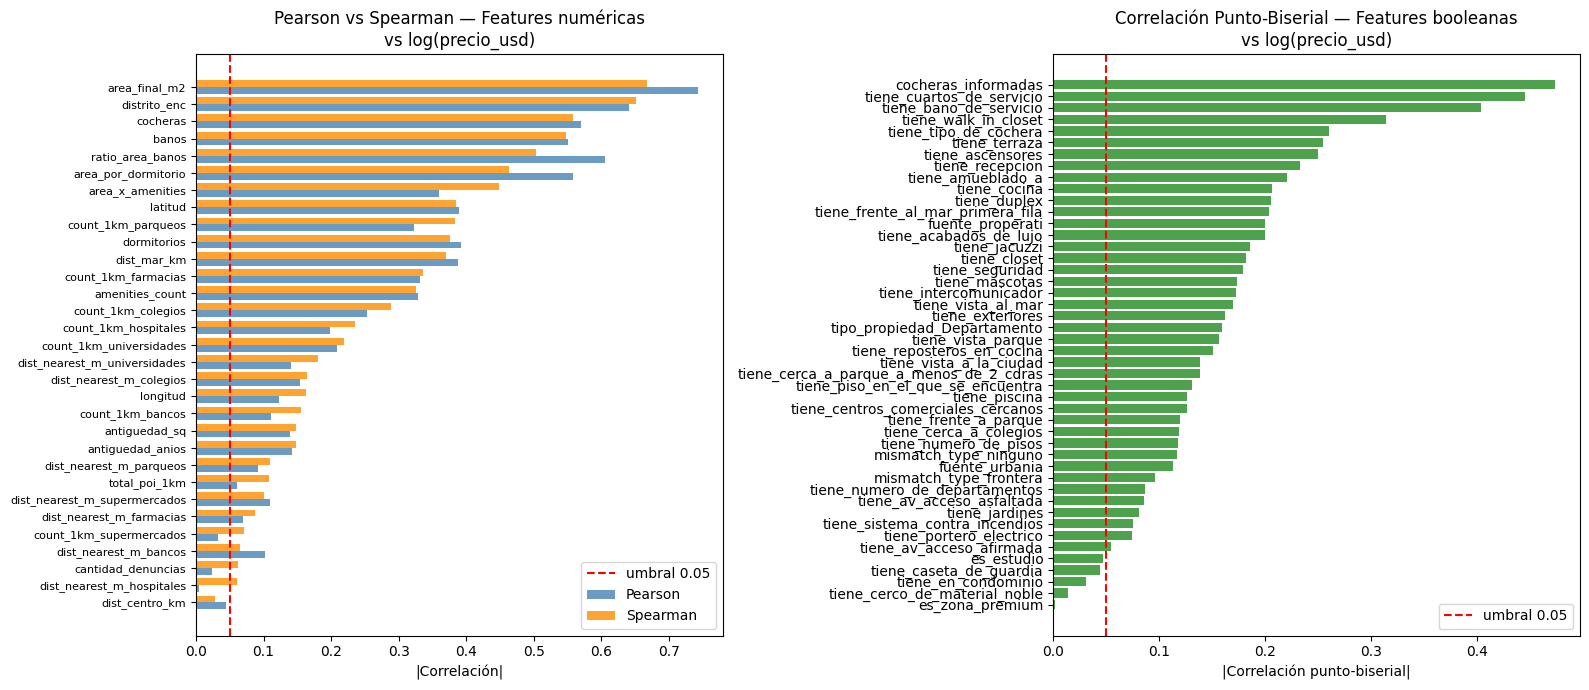

In [12]:
# Visualización comparativa Pearson vs Spearman (numéricas)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

corr_num_sorted = corr_num_df.sort_values('spearman', ascending=True)
y_pos = np.arange(len(corr_num_sorted))
axes[0].barh(y_pos - 0.2, corr_num_sorted['pearson'],  0.4, label='Pearson',  color='steelblue', alpha=0.8)
axes[0].barh(y_pos + 0.2, corr_num_sorted['spearman'], 0.4, label='Spearman', color='darkorange', alpha=0.8)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(corr_num_sorted.index, fontsize=8)
axes[0].axvline(0.05, color='red', linestyle='--', label='umbral 0.05')
axes[0].set_title('Pearson vs Spearman — Features numéricas\nvs log(precio_usd)')
axes[0].set_xlabel('|Correlación|')
axes[0].legend()

# Punto-biserial (booleanas)
pb_sorted = corr_bool_df.sort_values('punto_biserial', ascending=True)
axes[1].barh(pb_sorted.index, pb_sorted['punto_biserial'], color='forestgreen', alpha=0.8)
axes[1].axvline(0.05, color='red', linestyle='--', label='umbral 0.05')
axes[1].set_title('Correlación Punto-Biserial — Features booleanas\nvs log(precio_usd)')
axes[1].set_xlabel('|Correlación punto-biserial|')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES}03_correlacion_diferenciada.png', dpi=150)
plt.show()

### 7b. Selección de features — acción sobre baja correlación

Detectar baja correlación no implica eliminar automáticamente — una variable puede tener
baja correlación lineal pero capturar información no-lineal útil para los árboles,
o tener justificación de dominio para quedarse.

**Criterio de eliminación:** baja correlación en AMBAS métricas (Pearson < 0.05 Y Spearman < 0.05
para numéricas; punto-biserial < 0.03 para booleanas) **Y** sin justificación de dominio.

In [13]:
# Features numéricas candidatas a eliminar
cands_num = corr_num_df[
    (corr_num_df['pearson'] < 0.05) & (corr_num_df['spearman'] < 0.05)
].index.tolist()

# Features booleanas candidatas a eliminar
cands_bool = corr_bool_df[corr_bool_df['punto_biserial'] < 0.03].index.tolist()

print('Candidatas a eliminar (numéricas):', cands_num)
print('Candidatas a eliminar (booleanas):', cands_bool)

ELIMINAR_POR_CORR = [f for f in cands_num + cands_bool
                     if f not in ['latitud', 'longitud']]  # lat/lon se evalúan con VIF

print(f'\nFeatures a eliminar por baja correlación: {ELIMINAR_POR_CORR}')

if ELIMINAR_POR_CORR:
    for split in [X_train, X_val, X_test]:
        split.drop(columns=[c for c in ELIMINAR_POR_CORR if c in split.columns], inplace=True)
    FEATURES     = [f for f in FEATURES     if f not in ELIMINAR_POR_CORR]
    FEATURES_NUM = [f for f in FEATURES_NUM if f not in ELIMINAR_POR_CORR]
    FEATURES_BOOL= [f for f in FEATURES_BOOL if f not in ELIMINAR_POR_CORR]
    print(f'Features restantes: {len(FEATURES)}')

Candidatas a eliminar (numéricas): ['dist_centro_km']
Candidatas a eliminar (booleanas): ['tiene_cerco_de_material_noble', 'es_zona_premium']

Features a eliminar por baja correlación: ['dist_centro_km', 'tiene_cerco_de_material_noble', 'es_zona_premium']
Features restantes: 74


### 7c. Análisis de multicolinealidad — VIF

**VIF (Variance Inflation Factor)** mide cuánto se infla la varianza del coeficiente
de una variable debido a su correlación con las demás.

- VIF = 1 → sin multicolinealidad
- VIF 1–5 → aceptable
- VIF 5–10 → moderada, vigilar
- VIF > 10 → problemática → considerar eliminar o combinar variables

Solo se calcula para **modelos lineales** — en árboles (RF, XGBoost) la multicolinealidad
no afecta las predicciones, solo la interpretación de importancias.

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF sobre features numéricas
X_vif = X_train[FEATURES_NUM].copy()
X_vif = X_vif.assign(const=1)

vif_values = []
cols_vif = [c for c in X_vif.columns if c != 'const']
for i, col in enumerate(cols_vif):
    vif = variance_inflation_factor(X_vif.values, i)
    vif_values.append({'feature': col, 'VIF': round(vif, 2)})

vif_df = pd.DataFrame(vif_values).sort_values('VIF', ascending=False)

print('=== VIF por feature numérica ===')
print(vif_df.to_string(index=False))

altas = vif_df[vif_df['VIF'] > 10]
print(f'\nFeatures con VIF > 10 (multicolinealidad alta): {len(altas)}')
if len(altas) > 0:
    print(altas.to_string(index=False))

=== VIF por feature numérica ===
                     feature      VIF
               area_final_m2 58549.44
            ratio_area_banos 33596.16
                       banos 15402.32
            antiguedad_anios  1024.89
               antiguedad_sq  1024.19
               total_poi_1km   442.94
          count_1km_parqueos    36.45
        count_1km_hospitales    29.04
            count_1km_bancos    24.41
         count_1km_farmacias    24.37
          count_1km_colegios    13.99
                 dormitorios    13.69
     count_1km_universidades    10.78
         area_por_dormitorio    10.32
     count_1km_supermercados     6.62
                 dist_mar_km     6.41
                    longitud     5.57
                distrito_enc     5.05
                     latitud     4.40
            area_x_amenities     3.85
             amenities_count     3.17
       dist_nearest_m_bancos     2.44
                    cocheras     2.16
dist_nearest_m_universidades     1.81
     dist_nearest

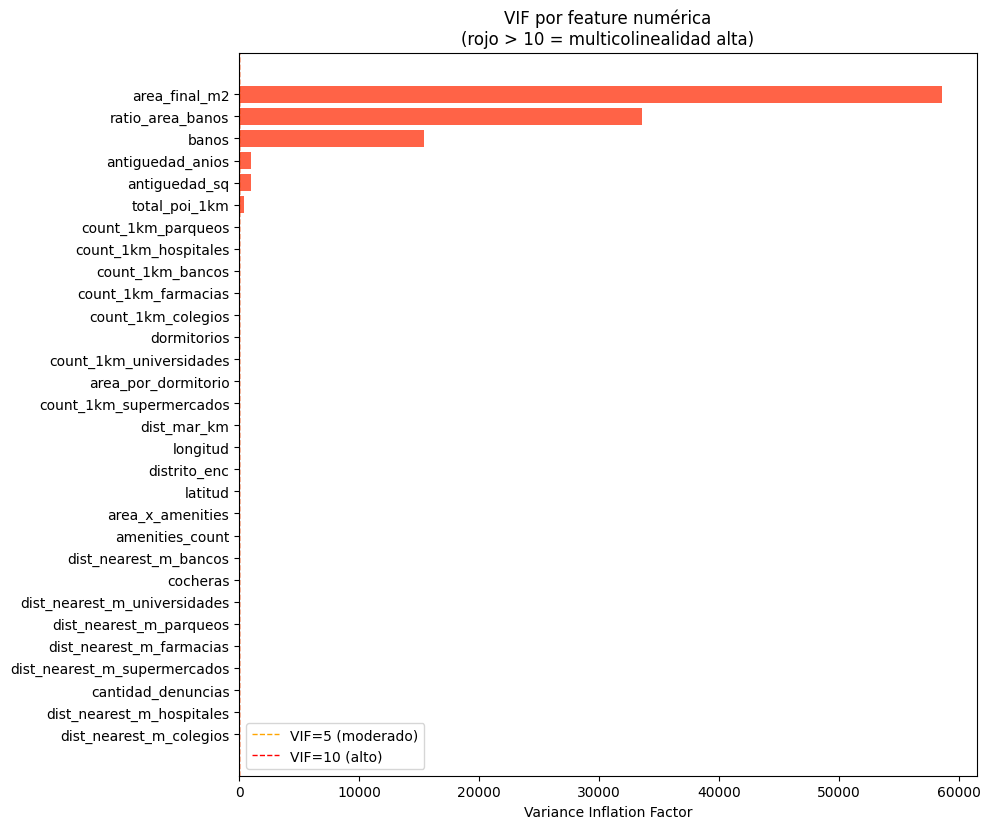

In [15]:
# Visualizar VIF
fig, ax = plt.subplots(figsize=(10, max(5, len(vif_df) * 0.28)))
colors = ['tomato' if v > 10 else ('orange' if v > 5 else 'steelblue')
          for v in vif_df['VIF']]
ax.barh(vif_df['feature'][::-1], vif_df['VIF'][::-1], color=colors[::-1])
ax.axvline(5,  color='orange', linestyle='--', linewidth=1, label='VIF=5 (moderado)')
ax.axvline(10, color='red',    linestyle='--', linewidth=1, label='VIF=10 (alto)')
ax.set_title('VIF por feature numérica\n(rojo > 10 = multicolinealidad alta)', fontsize=12)
ax.set_xlabel('Variance Inflation Factor')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}03_vif.png', dpi=150)
plt.show()

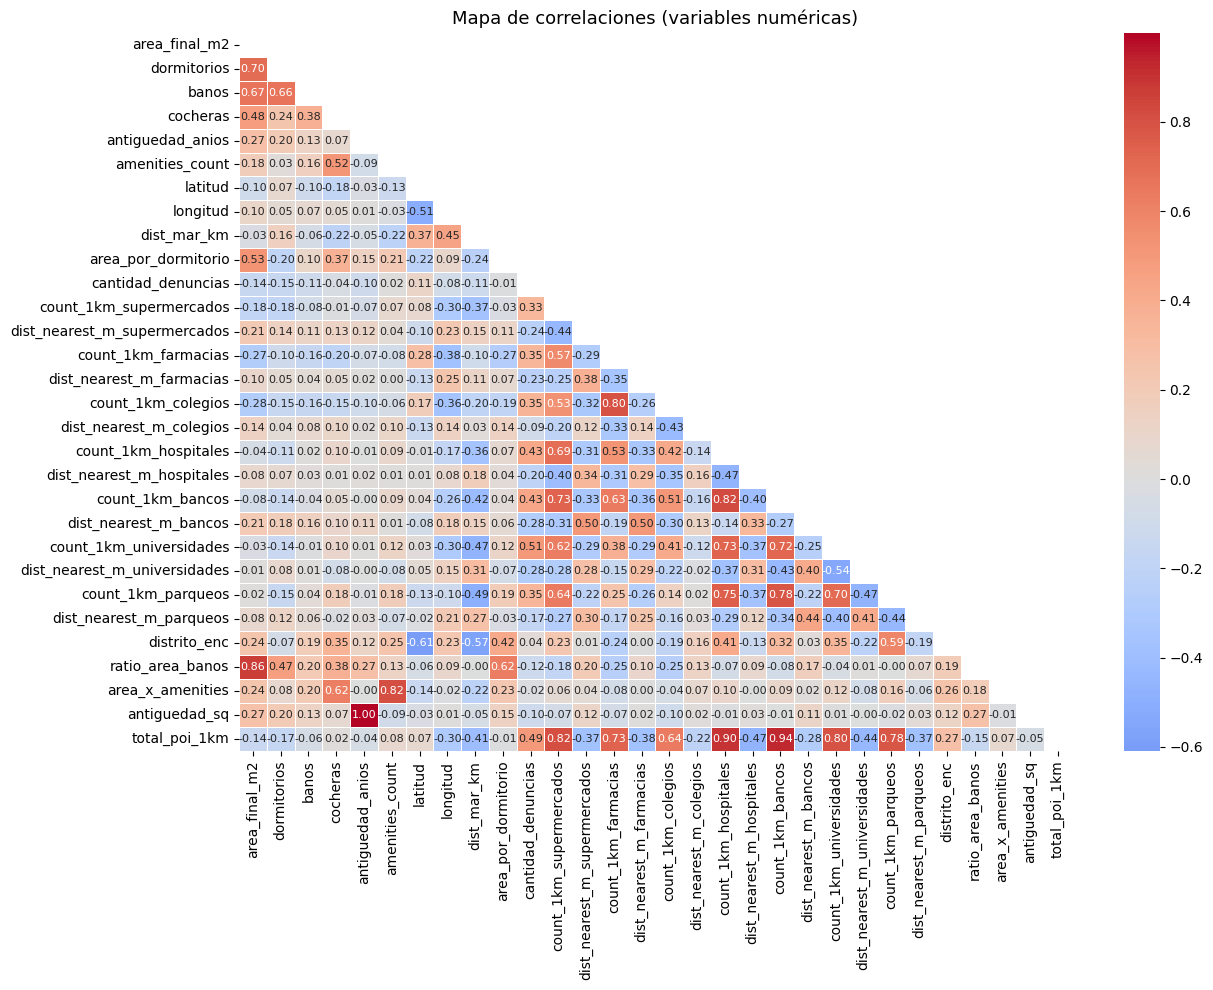

In [16]:
# Mapa de correlaciones entre features numéricas
corr_matrix = X_vif[FEATURES_NUM].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Mapa de correlaciones (variables numéricas)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES}02_correlaciones.png', dpi=150)
plt.show()

**DOCUMENTACIÓN DE MULTICOLINEALIDAD:**

1. Grupo 1 — VARIABLES DERIVADAS (correlación por construcción matemática):
  antiguedad_anios ↔ antiguedad_sq      r=0.999  (sq es el cuadrado de anios)
  area_final_m2   ↔ ratio_area_banos    r=0.864  (ratio incluye area en el numerador)

2. Grupo 2 — VARIABLES DE SUMA (total_poi_1km es la suma de los count_1km_*)
  total_poi_1km ↔ count_1km_bancos       r=0.936
  total_poi_1km ↔ count_1km_hospitales   r=0.895
  total_poi_1km ↔ count_1km_universidades r=0.796
  total_poi_1km ↔ count_1km_parqueos     r=0.785
  total_poi_1km ↔ count_1km_farmacias    r=0.733

**DECISIÓN JUSTIFICADA:**

  1. Objetivo del proyecto = PREDICCIÓN, no inferencia causal.

  2. La multicolinealidad NO afecta la calidad predictiva (RMSE, R²).
  Solo deteriora la INTERPRETABILIDAD de los coeficientes.

  Por modelo:
  - Linear Regression: coeficientes inestables, pero predicciones válidas.
    Si el objetivo fuera interpretar coeficientes, se eliminarían
    ratio_area_banos, antiguedad_sq y total_poi_1km (los derivados).
  - Ridge: regularización L2 distribuye el peso entre variables colineales.
    Maneja la multicolinealidad de forma natural. Sin acción requerida.
  - Lasso: regularización L1 puede llevar UNA de las colineales a cero,
    seleccionando automáticamente la más informativa. Sin acción requerida.
  - Random Forest / XGBoost: la multicolinealidad no afecta predicciones
    ni importancias en la práctica. Sin acción requerida.

**ACCIÓN: mantener todas las variables en todos los modelos.
    Documentar en notebook 04 que los coeficientes de Linear Regression
    no deben interpretarse causalmente por esta razón.**

In [17]:
# Correlación entre booleanas — detectar redundancias
corr_bool_matrix = X_train[FEATURES_BOOL].corr()
# Pares con correlación > 0.7 entre sí
pares_redundantes = []
for i in range(len(FEATURES_BOOL)):
    for j in range(i+1, len(FEATURES_BOOL)):
        c = corr_bool_matrix.iloc[i, j]
        if abs(c) > 0.7:
            pares_redundantes.append((FEATURES_BOOL[i], FEATURES_BOOL[j], round(c, 3)))

if pares_redundantes:
    print('Pares de booleanas con correlación > 0.7 (potencialmente redundantes):')
    for a, b, c in pares_redundantes:
        print(f'  {a}  ↔  {b}  (r={c})')
else:
    print('Ningún par de booleanas supera r=0.7 — sin redundancia significativa')

Pares de booleanas con correlación > 0.7 (potencialmente redundantes):
  tiene_bano_de_servicio  ↔  tiene_cuartos_de_servicio  (r=0.701)
  mismatch_type_frontera  ↔  mismatch_type_ninguno  (r=-0.918)


---
## 8. Guardado de artefactos

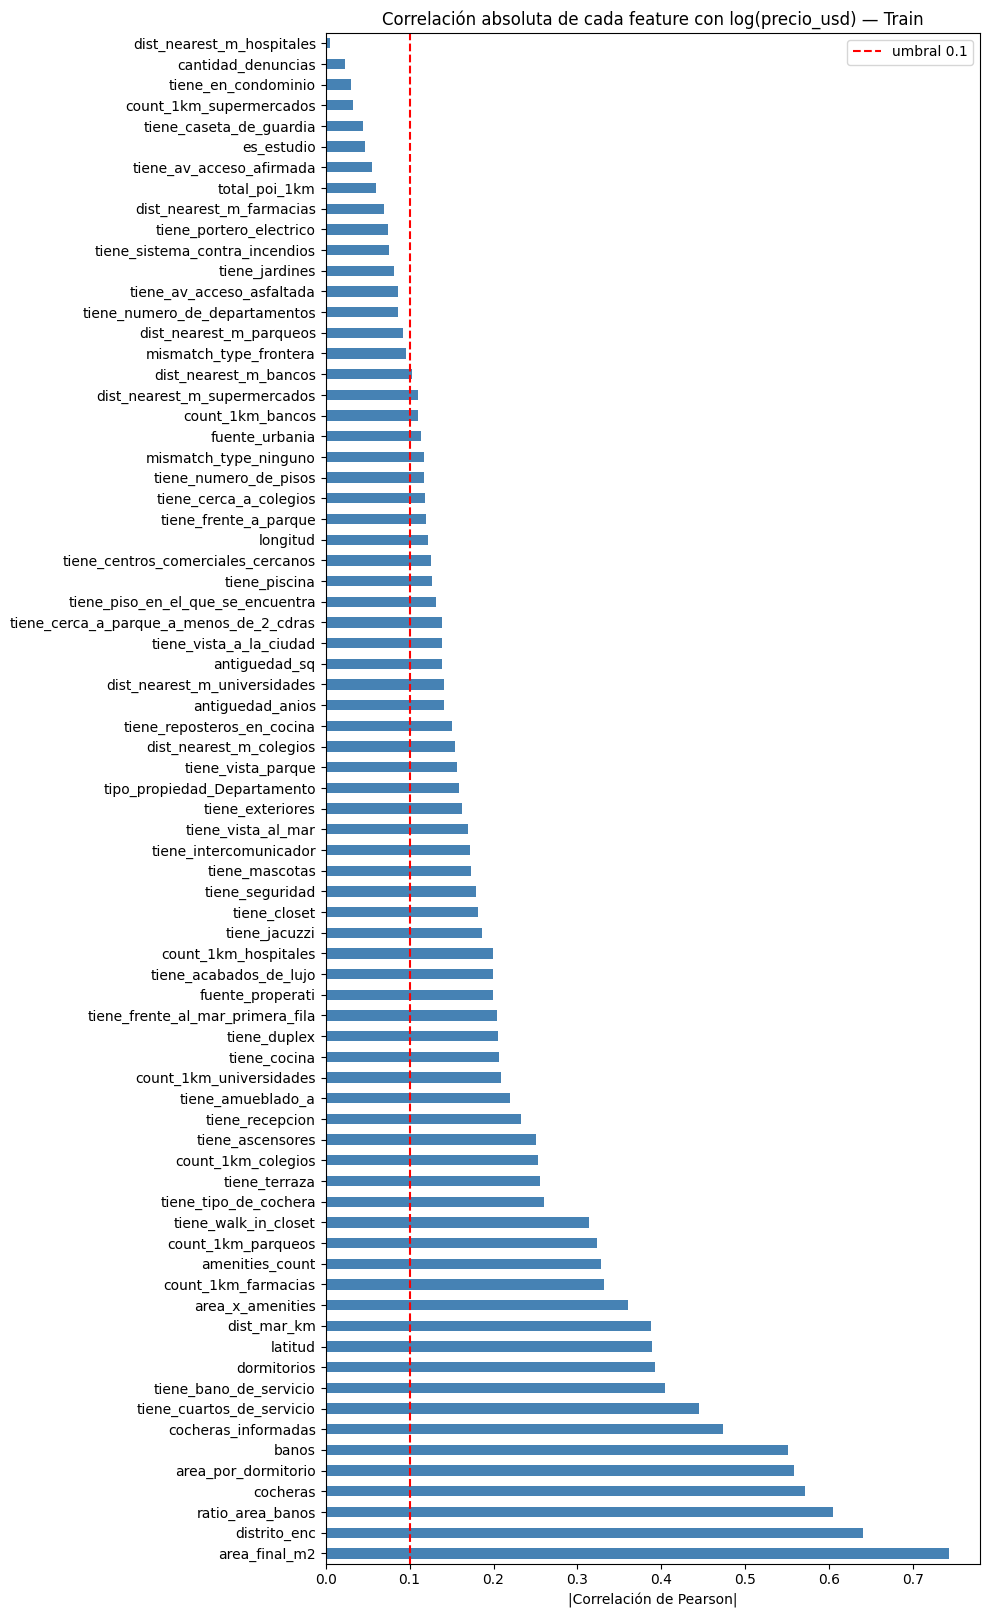


Features con correlación < 0.05 con el target (6):
es_estudio                   0.047299
tiene_caseta_de_guardia      0.044205
count_1km_supermercados      0.033222
tiene_en_condominio          0.030807
cantidad_denuncias           0.022984
dist_nearest_m_hospitales    0.004965


In [18]:
# Correlación de cada feature con el target en train
corr_target = X_train.corrwith(pd.Series(y_train, index=X_train.index)).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(FEATURES) * 0.22)))
corr_target.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Correlación absoluta de cada feature con log(precio_usd) — Train', fontsize=12)
ax.set_xlabel('|Correlación de Pearson|')
ax.axvline(0.1, color='red', linestyle='--', label='umbral 0.1')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}03_correlacion_features_target.png', dpi=150)
plt.show()

# Features con muy baja correlación
bajas = corr_target[corr_target < 0.05]
print(f'\nFeatures con correlación < 0.05 con el target ({len(bajas)}):')
print(bajas.to_string())

---
## 8. Guardado de artefactos

In [19]:
import os

# Guardar splits
X_train.to_csv(f'{PROCESSED}X_train.csv', index=False)
X_val.to_csv(f'{PROCESSED}X_val.csv',   index=False)
X_test.to_csv(f'{PROCESSED}X_test.csv', index=False)

pd.Series(y_train).to_csv(f'{PROCESSED}y_train.csv', index=False, header=['log_precio'])
pd.Series(y_val).to_csv(f'{PROCESSED}y_val.csv',   index=False, header=['log_precio'])
pd.Series(y_test).to_csv(f'{PROCESSED}y_test.csv', index=False, header=['log_precio'])

# Guardar versiones escaladas como numpy
np.save(f'{PROCESSED}X_train_sc.npy', X_train_sc)
np.save(f'{PROCESSED}X_val_sc.npy',   X_val_sc)
np.save(f'{PROCESSED}X_test_sc.npy',  X_test_sc)

# Guardar scaler y lista de features
joblib.dump(scaler,   f'{MODELS}scaler.joblib')
joblib.dump(FEATURES, f'{MODELS}feature_names.joblib')

print('- Artefactos guardados:')
for f in sorted(os.listdir(PROCESSED)):
    print(f'   data/processed/{f}')
for f in sorted(os.listdir(MODELS)):
    print(f'   models/{f}')

- Artefactos guardados:
   data/processed/X_test.csv
   data/processed/X_test_sc.npy
   data/processed/X_train.csv
   data/processed/X_train_sc.npy
   data/processed/X_val.csv
   data/processed/X_val_sc.npy
   data/processed/inmuebles_clean_v1.csv
   data/processed/resultados_modelos.csv
   data/processed/resultados_test.csv
   data/processed/y_test.csv
   data/processed/y_train.csv
   data/processed/y_val.csv
   models/01_linear_regression.joblib
   models/02_ridge.joblib
   models/03_lasso.joblib
   models/04_random_forest.joblib
   models/05_xgboost.joblib
   models/feature_names.joblib
   models/feature_names_sc.joblib
   models/features_log_transformed.joblib
   models/modelo_final.joblib
   models/outlier_caps.joblib
   models/scaler.joblib
   models/target_enc_distrito.joblib


---
## Resumen del Feature Engineering

| Decisión | Justificación |
|----------|---------------|
| `log1p(precio_usd)` como target | Reduce skewness, mejora modelos lineales, reduce peso de outliers |
| `log1p` a predictoras con skewness > 1 | Lineariza la relación feature→target para modelos lineales |
| StandardScaler solo en features numéricas | Las booleanas {0,1} no se escalan: coeficiente directamente interpretable |
| Target Encoding para `distrito_oficial` | Alta cardinalidad (~49 valores), evita explosión dimensional |
| OHE para `fuente`, `tipo_propiedad`, `mismatch_type` | Baja cardinalidad (≤ 4 valores), riesgo de dimensionalidad bajo |
| Split 70/15/15 antes del encoding y escalado | Evita data leakage |
| Pearson + Spearman para numéricas | Detecta tanto relaciones lineales como monotónicas |
| Punto-biserial para booleanas | Medida correcta cuando una variable es binaria |
| VIF para multicolinealidad | Detecta features redundantes que inflarían coeficientes en modelos lineales |
| Eliminación por baja correlación en ambas métricas | Evitar eliminar features con relaciones no-lineales útiles para árboles |